In [17]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import r2_score
from typing import Sequence
from dataclasses import dataclass
from typing import NamedTuple
from typing import Mapping
from typing import TypeAlias
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy import stats

sys.path.append('C:\\Users\\evils\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData

# utils

In [18]:
"""АННОТАЦИЯ ТИПОВ"""
FuelCombination: TypeAlias = str

class ApproxData(NamedTuple):
    """Аппроксимированная поверхность со значением расхода топлива и вводимого компонента"""
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    approximated_surface: np.ndarray

class DiffData(NamedTuple):
    """Дифференциальная поверхность со значением расхода топлива и вводимого компонента"""
    fuel_consumption: np.ndarray
    additive_consumption: np.ndarray
    diff_surface: np.ndarray

class MinPoints(NamedTuple):
    """Координаты минимимальных значений каждой строки в матрице"""
    x: np.ndarray
    y: np.ndarray

class LinearCoeffs(NamedTuple):
    """Коэффициенты линейной прямой"""
    angular_coefficient: float  # Угловой коэффицент
    b: float

class LevelPoints(NamedTuple):
    """Координаты выбранного уровне contourf"""
    x: np.ndarray
    y: np.ndarray

"""ОШИБКИ"""

def fuel_combination_key_error() -> KeyError:
    return KeyError('Сочетание топлива, добавки и компонента не найдено в словаре!')

"""ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ"""

def get_fuels_combinations(CO=True) -> list[FuelCombination]:
    if CO:
        fuel_combinations = [
            'diesel_steam_CO',
            'crude_oil_steam_CO',
            'heavy_oil_steam_CO',
            'kerosene_steam_CO',
            'waste_oil_steam_CO',
            'waste_oil_40_2024_steam_CO',
            'waste_oil_60_2024_steam_CO'
        ]
    else:
        fuel_combinations = [
            'diesel_steam_O2',
            'crude_oil_steam_O2',
            'heavy_oil_steam_O2',
            'kerosene_steam_O2',
            'waste_oil_steam_O2',\
        ]
    return fuel_combinations

def title_on_russian(title: str) -> str:
    translate = {
        'diesel': 'Дизельное топливо',
        'diesel, CO': 'Дизельное топливо, CO',
        'diesel_steam_CO': 'Дизельное топливо, CO',
        'crude_oil_steam_CO': 'Сырая нефть, CO',
        'heavy_oil_steam_CO': 'Мазут, CO',
        'kerosene_steam_CO': 'Керосин, CO',
        'waste_oil_steam_CO': 'Отработанное масло, CO'
    }
    return translate.get(title, title)

"""ПОЛУЧЕНИЕ ПОВЕРХНОСТЕЙ"""

def get_rbf_data(CO=True) -> Mapping[FuelCombination, ApproxData]:
    fuel_combinations = get_fuels_combinations(CO=CO)
    rbf_data = {}
    
    for fuel_combination in fuel_combinations:
        ex = ExperimentData()
        ex.get_experiment_data(*delete_underline(fuel_combination))
        rbf_data[fuel_combination] = ex.get_rbf_data()
    return rbf_data

def get_diff_data(CO=True) -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data(CO=CO)
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[5:] - surf[:-5])
        add_cons_diff = add_cons[5:]
        diff_data[fuel_combination] = fuel_cons, add_cons_diff, diff
    return diff_data


def get_diff_data(CO=True) -> Mapping[FuelCombination, DiffData]:
    rbf_data = get_rbf_data(CO=CO)
    diff_data = {}
    for fuel_combination in rbf_data:
        fuel_cons, add_cons, surf = rbf_data[fuel_combination]

        diff = np.abs(surf[:, 0:95] - surf[:, 5:100])
        fuel_cons_diff = fuel_cons[5:]
        diff_data[fuel_combination] = fuel_cons_diff, add_cons, diff
    return diff_data



"""ЛИНИЯ МИНИМАЛЬНЫХ КОНЦЕНТРАЦИЙ CO"""

def _get_min_CO(data: Mapping[FuelCombination, ApproxData]) -> Mapping[FuelCombination, MinPoints]:
    """В апроксимированной матрице находит минимальные значения в каждой строке матрицы"""
    min_CO = {}
    
    for fuel_combination in data:
        fuel, additive, surf = data[fuel_combination]
        df = pd.DataFrame(surf, columns=fuel, index=additive)
        df = df.idxmin(axis=1)
        min_x = list(df)
        min_y = list(df.index)
        min_CO[fuel_combination] = min_x, min_y
    return min_CO

def _linear(x, a, b):
    return a * x + b
    
def rotate_line(a: float, b: float, angle: float, mid_x: float, offset: int=0) -> tuple:
    theta = np.radians(angle)
    
    mid_y = a * mid_x + b
    
    new_a = a * np.cos(theta) - (mid_y - b) * np.sin(theta)
    new_b = mid_y - new_a * mid_x - offset  # Включаем смещение
    
    return new_a, new_b

def get_linear_coeffs_min_CO() -> Mapping[FuelCombination, LinearCoeffs]:
    rbf_data = get_rbf_data(CO=True)
    min_CO = _get_min_CO(rbf_data)
    coeffs = {}
    
    # Задайте углы поворота для определённых fuel_combination
    rotation_angles = {
        'waste_oil_steam_CO': 5,
        'waste_oil_40_2024_steam_CO': 17,
        'waste_oil_60_2024_steam_CO': 17
    }
    fuels_to_offset = {
        'waste_oil_steam_CO': 0.025,
        'waste_oil_60_2024_steam_CO': 0.1
    }
        
    for fuel_combination in min_CO:
        min_x, min_y = min_CO[fuel_combination]
        params, _ = curve_fit(_linear, min_x, min_y)
        a, b = params
        
        # Вычисляем середину для поворота
        mid_x = (min_x[0] + min_x[-1]) / 2
        
        # Если комбинация топлива в словаре, примените поворот
        if fuel_combination in rotation_angles:
            angle = rotation_angles[fuel_combination]
            if fuel_combination in fuels_to_offset:
                 a, b = rotate_line(a, b, angle, mid_x, offset=fuels_to_offset[fuel_combination])
            else:
                a, b = rotate_line(a, b, angle, mid_x)

        coeffs[fuel_combination] = a, b
    
    return coeffs

def delete_underline(string_with_underline: str) -> tuple:
    parts = string_with_underline.split('_')
    # Находим индекс "steam" и объединяем все части до него
    steam_index = parts.index('steam')
    fuel_name = '_'.join(parts[:steam_index])
    return (fuel_name, parts[steam_index], parts[steam_index + 1])

"""ЛИНИИ МАКСИМАЛЬНОГО ГРАДИЕНТА"""

def get_contours(data: Mapping[FuelCombination, ApproxData | DiffData], contour_level) -> Mapping[FuelCombination, LevelPoints]:
    level_data = {}
        
    for fuel_combination in data:
        fig, ax = plt.subplots()
        
        x, y, surf = data[fuel_combination]
        contours = plt.contourf(x, y, surf, colors='none')
        '''
        if fuel_combination == 'waste_oil_60_2024_steam_CO':
            contour_level = 2
        '''
            
        selected_contour = contours.collections[contour_level]
        path = selected_contour.get_paths()[0]
        points = path.vertices

        level_x, level_y = points[:, 0], points[:, 1]
        level_data[fuel_combination] = level_x, level_y

        ax.remove()
        plt.close(fig)
    return level_data

def _classify_by_line(MinPoints, LinearCoeffs) -> np.array:
    x, y = MinPoints
    a, b = LinearCoeffs
    result = y - a * x - b
    
    classification = np.where(result > 0, 1, 2)
    return classification

def _get_class(x: np.ndarray, y: np.ndarray, predicted_class: np.ndarray, class_number: int) -> LevelPoints:
    x_selected = []
    y_selected = []
    
    for i in range(len(predicted_class)):
        if predicted_class[i] == class_number:
            x_selected.append(x[i])
            y_selected.append(y[i])
    return np.array(x_selected), np.array(y_selected)

def get_linear_coeffs_div_line(data: Mapping[FuelCombination, DiffData], contour_level: int, cls: int=2) -> Mapping[FuelCombination, MinPoints]:
    data = get_rbf_data(CO=True)
    linear_coeffs = {}
    min_coeffs = get_linear_coeffs_min_CO()
    contour_data = get_contours(data, contour_level)

    # Задайте углы поворота для определённых fuel_combination
    '''
    rotation_angles = {
        'diesel_steam_CO': 0,
        'kerosene_steam_CO': 20,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 10,
        'waste_oil_60_2024_steam_CO': 15
    }
    fuels_to_offset = {
        'diesel_steam_CO': 0.05,
        'kerosene_steam_CO': -0.4,
        'waste_oil_steam_CO': 0.1,
        'waste_oil_40_2024_steam_CO': 0.07,
        'waste_oil_60_2024_steam_CO': -0.1
    }
    '''
    rotation_angles = {
        'diesel_steam_CO': 8,
        'kerosene_steam_CO': 0,
        'heavy_oil_steam_CO': 5,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 0,
        'waste_oil_60_2024_steam_CO': 15
    }
    fuels_to_offset = {
        'diesel_steam_CO': -0.05,
        'kerosene_steam_CO': 0,
        'heavy_oil_steam_CO': -0.1,
        'waste_oil_steam_CO': 0,
        'waste_oil_40_2024_steam_CO': 0.05,
        'waste_oil_60_2024_steam_CO': -0.3
    }
    
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        a, b = min_coeffs[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        
        classified = _classify_by_line((x_level, y_level), (a, b))
        x_selected, y_selected = _get_class(x_level, y_level, classified, cls)
        params, _ = curve_fit(_linear, x_selected, y_selected)
        a, b = params

        # Вычисляем середину для поворота
        mid_x = (x[0] + x[-1]) / 2
        
        # Если комбинация топлива в словаре, примените поворот
        if fuel_combination in rotation_angles:
            angle = rotation_angles[fuel_combination]
            if fuel_combination in fuels_to_offset:
                 a, b = rotate_line(a, b, angle, mid_x, offset=fuels_to_offset[fuel_combination])
            else:
                a, b = rotate_line(a, b, angle, mid_x)
        
        linear_coeffs[fuel_combination] = a, b
        
    return linear_coeffs

def show_contours(data: Mapping[FuelCombination, DiffData], contour_level) -> None:
    contour_data = get_contours(data, contour_level)
        
    for fuel_combination in data:
        x, y, surf = data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]
        plt.title(fuel_combination)
        plt.contourf(x, y, surf)

        plt.scatter(x_level, y_level, c='black')
        plt.show()
        plt.close()

"""СРЕДНЕЕ"""
def get_mean_coeffs(
    grad_coeffs: Mapping[FuelCombination, LinearCoeffs], 
    min_coeffs: Mapping[FuelCombination, LinearCoeffs]
) -> Mapping[FuelCombination, LinearCoeffs]:
    coeffs = {}
    
    for fuel_combination in min_coeffs:
        a = (grad_coeffs[fuel_combination][0] + min_coeffs[fuel_combination][0]) / 2
        b = (grad_coeffs[fuel_combination][1] + min_coeffs[fuel_combination][1]) / 2
        coeffs[fuel_combination] = a, b
    return coeffs

# Анализ количества воздуха

In [19]:
def get_J_sum_air_plot():
    fuel_combinations = get_fuels_combinations()
    ex = ExperimentData()
    ex.get_experiment_data(*delete_underline(fuel_combination))
    print(ex.data)

get_J_sum_air_plot()

AttributeError: 'ExperimentData' object has no attribute 'data'

# Линии минимальных концентраций CO

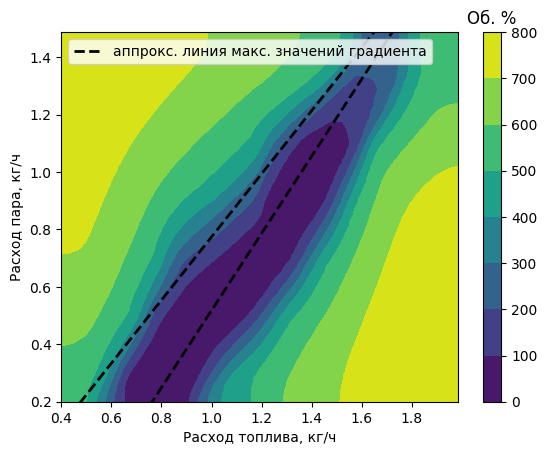

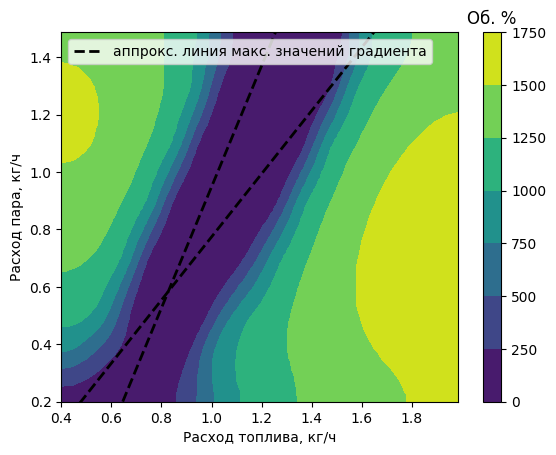

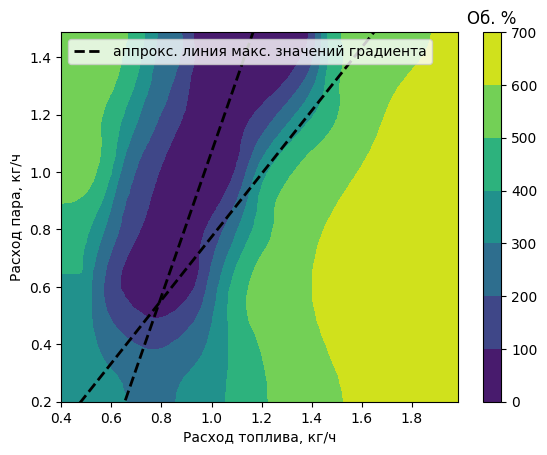

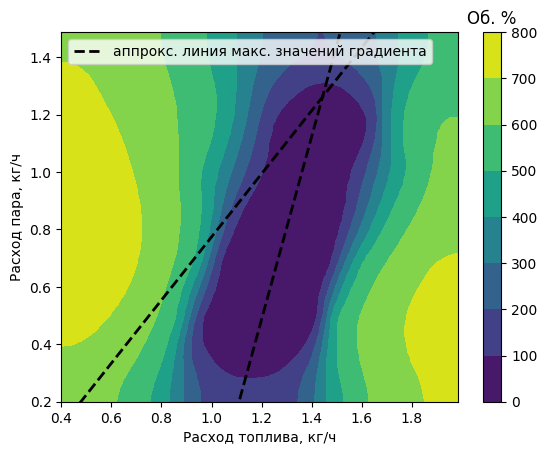

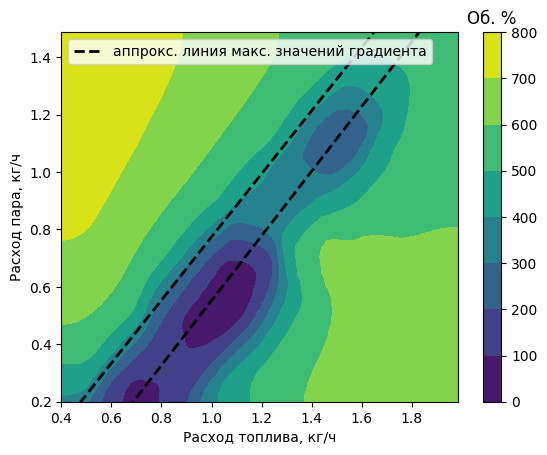

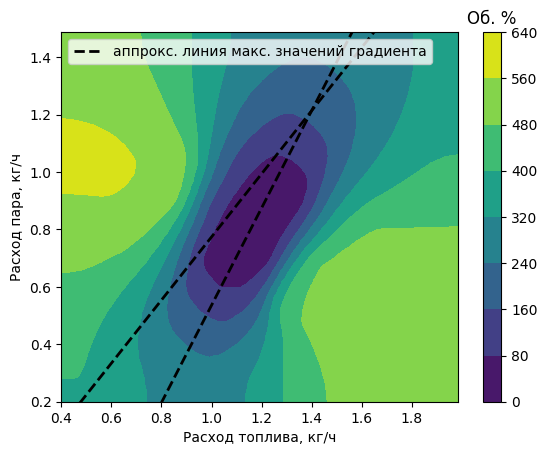

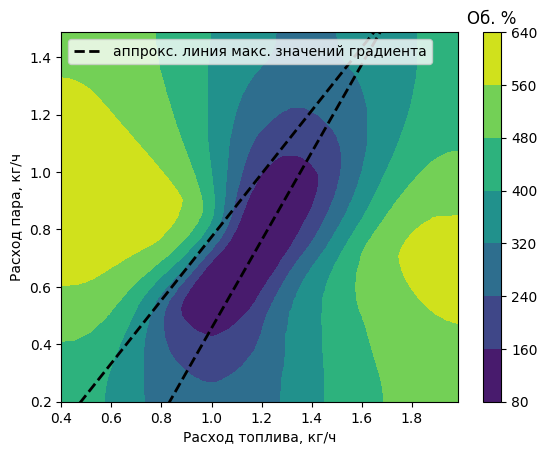

In [21]:
rbf_data = get_rbf_data(CO=True)
min_CO_coeffs = get_linear_coeffs_min_CO()
for fuel_combination in min_CO_coeffs:
    fuel_consumption, additive_consumption, component_approximation = rbf_data[fuel_combination]
    min_approx = _linear(fuel_consumption, *min_CO_coeffs[fuel_combination])
    fig, ax = plt.subplots()
    plt.contourf(fuel_consumption, additive_consumption, component_approximation)
    x_min, y_min = _get_min_CO(rbf_data)[fuel_combination]
    
    min_approx_r2 = _linear(np.linspace(min(x_min), max(x_min), num=100), *min_CO_coeffs[fuel_combination])

    # Вычисление коэффициента детерминации R^2
    r_squared = r2_score(list(reversed(y_min)), min_approx_r2)
    # Первый массив (значения от 0.4 до 1.984 с шагом 0.016)
    array1 = np.arange(0.4, 1.984 + 0.016, 0.016)
    x_values = [0.4, 0.416, 0.432, 0.448, 0.464, 0.48, 0.496, 0.512, 0.528, 0.544, 0.56, 0.576, 0.592, 0.608, 0.624, 0.64, 0.656, 0.672, 0.688, 0.704, 0.72, 0.736, 0.752, 0.768, 0.784, 0.8, 0.816, 0.832, 0.848, 0.864, 0.88, 0.896, 0.912, 0.928, 0.944, 0.96, 0.976, 0.992, 1.008, 1.024, 1.04, 1.056, 1.072, 1.088, 1.104, 1.12, 1.136, 1.152, 1.168, 1.184, 1.2, 1.216, 1.232, 1.248, 1.264, 1.28, 1.296, 1.312, 1.328, 1.344, 1.36, 1.376, 1.392, 1.408, 1.424, 1.44, 1.456, 1.472, 1.488, 1.504, 1.52, 1.536, 1.552, 1.568, 1.584, 1.6, 1.616, 1.632, 1.648, 1.664, 1.68, 1.696, 1.712, 1.728, 1.744, 1.76, 1.776, 1.792, 1.808, 1.824, 1.84, 1.856, 1.872, 1.888, 1.904, 1.92, 1.936, 1.952, 1.968, 1.984]
    y_values = [0.11410009, 0.13169768, 0.14929527, 0.16689286, 0.18449044, 0.20208803, 0.21968562, 0.23728321, 0.2548808, 0.27247838, 0.29007597, 0.30767356, 0.32527115, 0.34286873, 0.36046632, 0.37806391, 0.3956615, 0.41325909, 0.43085667, 0.44845426, 0.46605185, 0.48364944, 0.50124703, 0.51884461, 0.5364422, 0.55403979, 0.57163738, 0.58923497, 0.60683255, 0.62443014, 0.64202773, 0.65962532, 0.6772229, 0.69482049, 0.71241808, 0.73001567, 0.74761326, 0.76521084, 0.78280843, 0.80040602, 0.81800361, 0.8356012, 0.85319878, 0.87079637, 0.88839396, 0.90599155, 0.92358914, 0.94118672, 0.95878431, 0.9763819, 0.99397949, 1.01157707, 1.02917466, 1.04677225, 1.06436984, 1.08196743, 1.09956501, 1.1171626, 1.13476019, 1.15235778, 1.16995537, 1.18755295, 1.20515054, 1.22274813, 1.24034572, 1.2579433, 1.27554089, 1.29313848, 1.31073607, 1.32833366, 1.34593124, 1.36352883, 1.38112642, 1.39872401, 1.4163216, 1.43391918, 1.45151677, 1.46911436, 1.48671195, 1.50430954, 1.52190712, 1.53950471, 1.5571023, 1.57469989, 1.59229747, 1.60989506, 1.62749265, 1.64509024, 1.66268783, 1.68028541, 1.697883, 1.71548059, 1.73307818, 1.75067577, 1.76827335, 1.78587094, 1.80346853, 1.82106612, 1.83866371, 1.85626129]

    # Второй массив (линейно распределенные значения между -0.53122549 и 1.48568399)
    array2 = np.linspace(-0.53122549, 1.48568399, 100)
    #plt.plot(x_min, y_min, c='orange', linewidth=1, label='мин. концентрация CO')
    plt.plot(x_values, y_values, c='black', linestyle='dashed', linewidth=2)
    plt.plot(fuel_consumption, min_approx, c='black', linestyle='dashed', linewidth=2, label='аппрокс. линия макс. значений градиента')
    clb = plt.colorbar()
    clb.ax.set_title('Об. %')
    ax.set_xlabel('Расход топлива, кг/ч')
    ax.set_ylabel('Расход пара, кг/ч')
    plt.legend(loc='upper left')
    plt.ylim(min(additive_consumption), max(additive_consumption))
    #plt.title(f'{title_on_russian(fuel_combination)}, коэф. детерм. = {r_squared:.2f}')
    plt.show()
    plt.close()

# Линии максимального градиента

In [22]:
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, 2)
for fuel_combination in diff_data:
        x, y, surf = diff_data[fuel_combination]
        print(len(x), len(y), surf.shape)

95 100 (100, 95)
95 100 (100, 95)
95 100 (100, 95)
95 100 (100, 95)
95 100 (100, 95)
95 100 (100, 95)
95 100 (100, 95)


C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


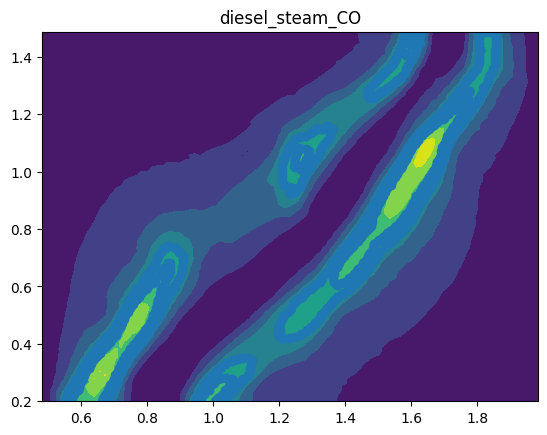

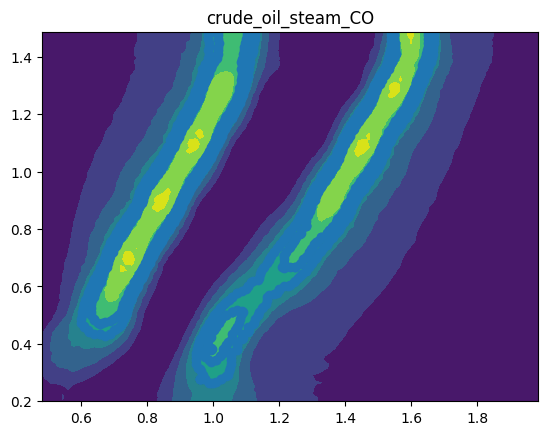

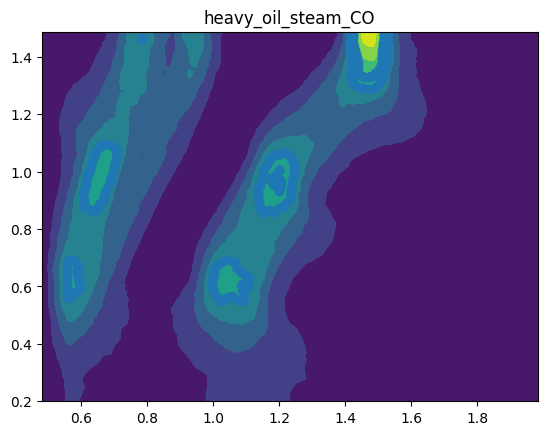

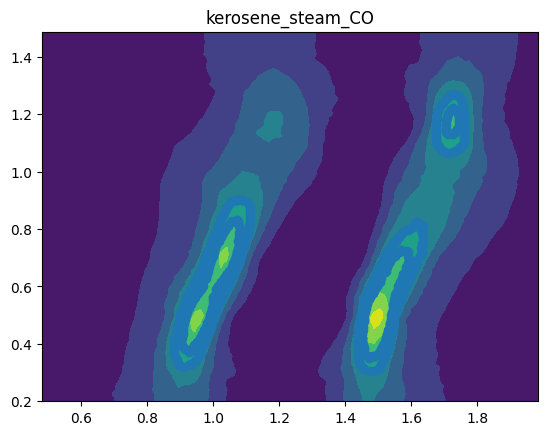

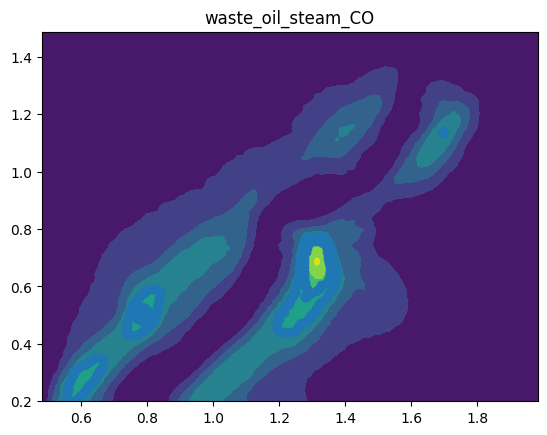

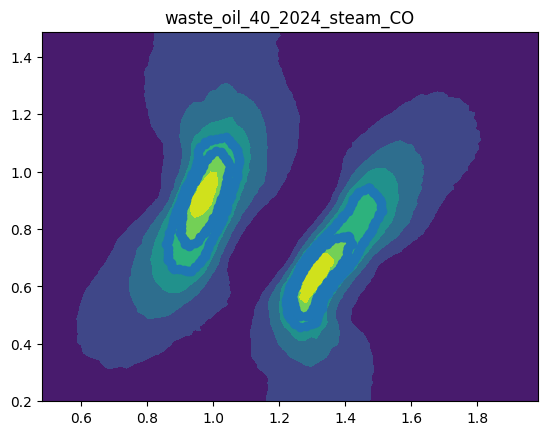

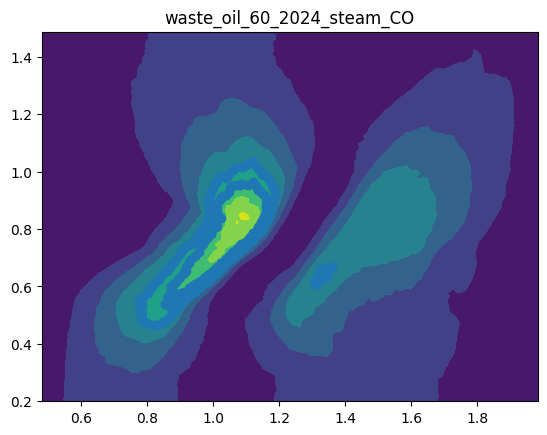

In [23]:
diff_data = get_diff_data()
contour_data = get_contours(diff_data, contour_level=4)
for fuel_combination in diff_data:
        x, y, surf = diff_data[fuel_combination]
        x_level, y_level = contour_data[fuel_combination]

        plt.title(fuel_combination)
        plt.contourf(x, y, surf)
        plt.scatter(x_level, y_level)
        plt.show()
        plt.close()
        

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


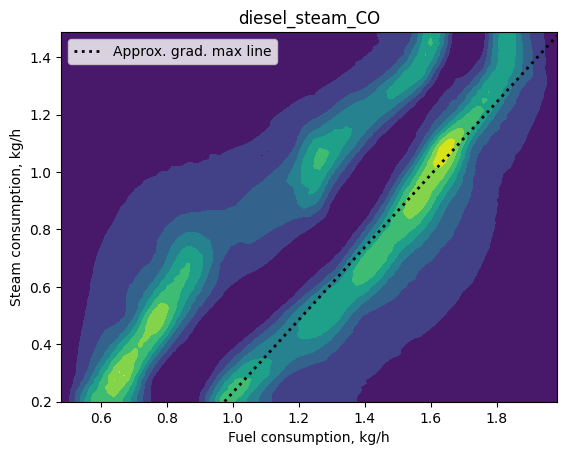

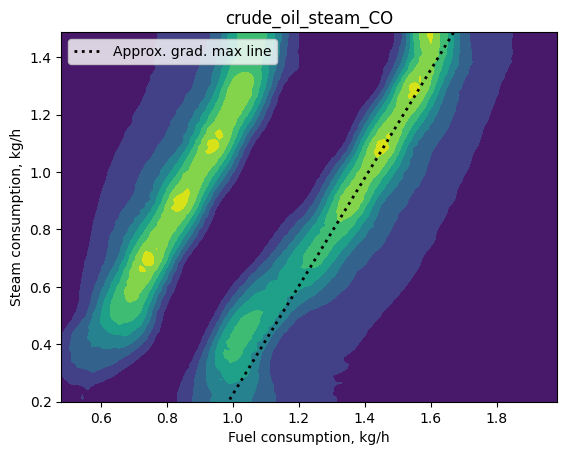

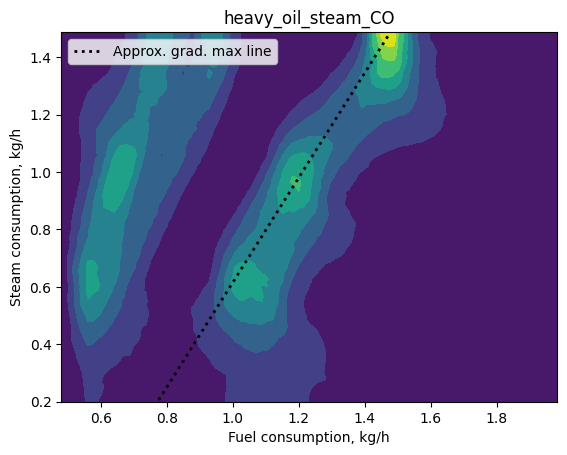

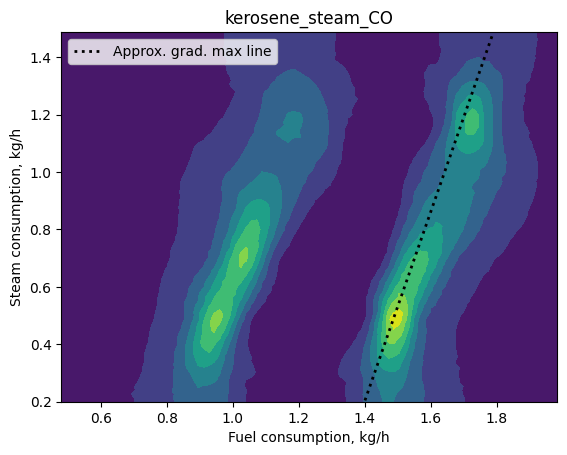

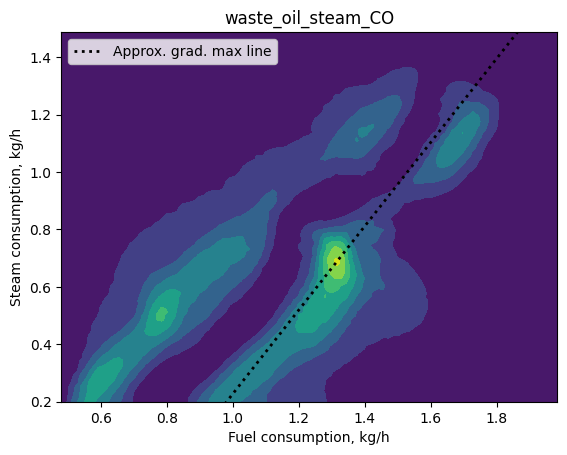

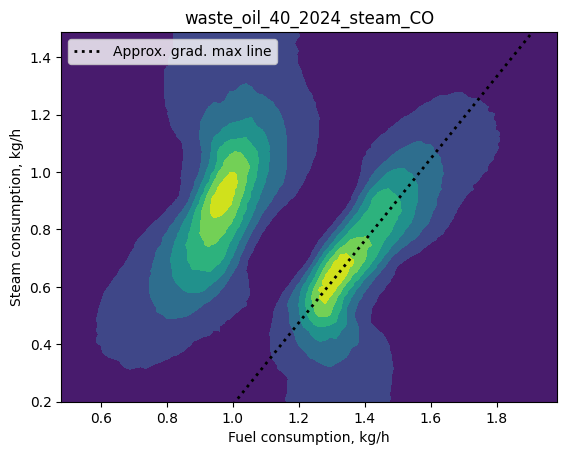

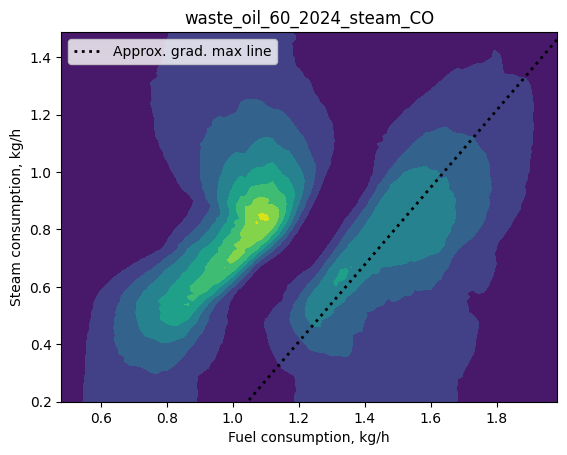

In [25]:
contour_level = 3
diff_data = get_diff_data(CO=True)
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, contour_level)
for fuel_combination in diff_data:
        x, y, surf = diff_data[fuel_combination]
        a, b = div_line_coeffs_high_line[fuel_combination]  # Выбор верхней линии макс. град
        max_grad = _linear(x, a, b)
        contour_data = get_contours(diff_data, contour_level)
        x_level, y_level = contour_data[fuel_combination]
        
        classified = _classify_by_line((x_level, y_level), (a, b))
        fig, ax = plt.subplots()
        plt.contourf(x, y, surf)
        plt.plot(x, max_grad, c='black', linestyle='dotted', linewidth=2, label='Approx. grad. max line')
        plt.xlabel('Fuel consumption, kg/h')
        plt.ylabel('Steam consumption, kg/h')
        plt.ylim(min(y), max(y))
        plt.title(fuel_combination)
        plt.legend()
        plt.show()
        plt.close()
        

# Условие оптимального режима

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


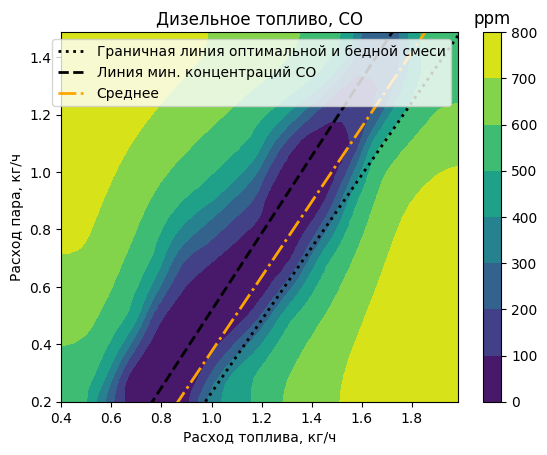

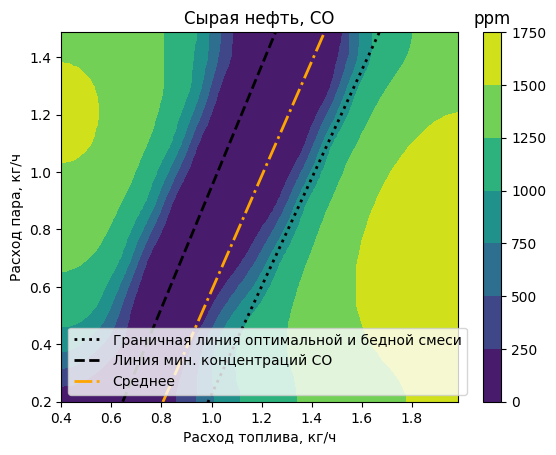

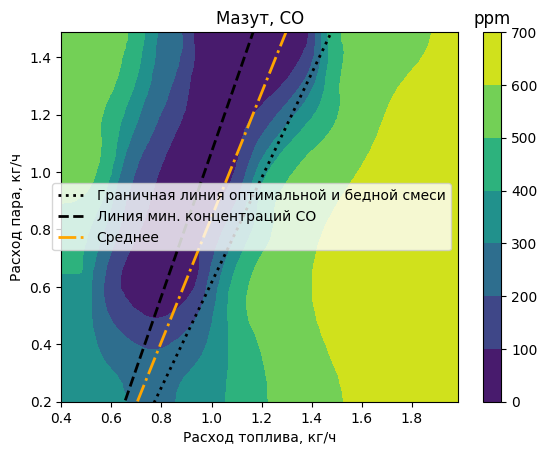

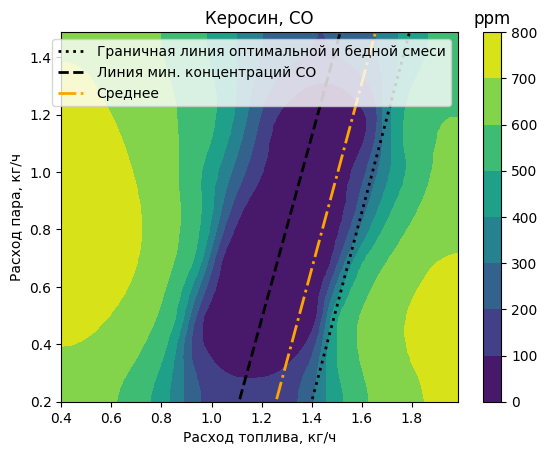

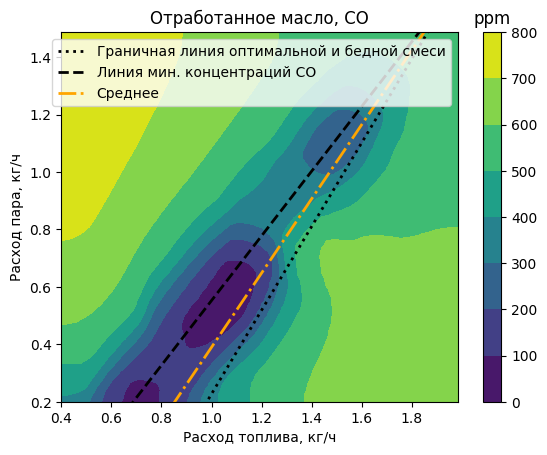

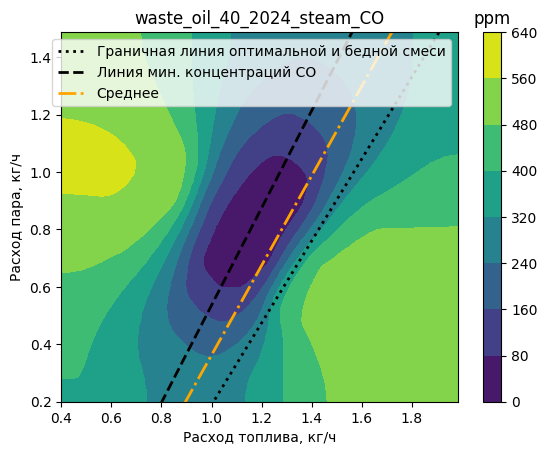

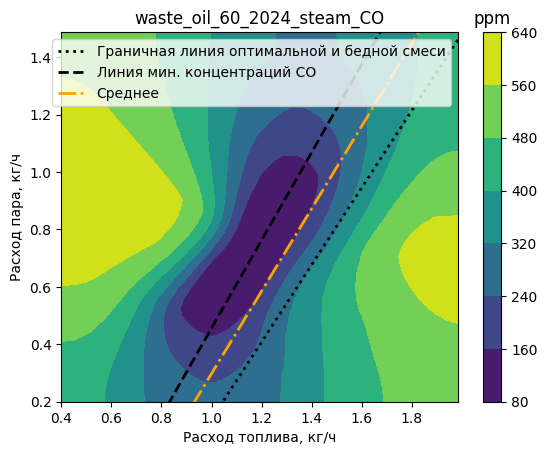

In [26]:


rbf_data = get_rbf_data()
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, 3)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

for fuel_combination in rbf_data:
    fuel_cons, add_cons_diff, diff = rbf_data[fuel_combination]
    grad_approx = _linear(fuel_cons, *div_line_coeffs_high_line[fuel_combination])
    min_approx = _linear(fuel_cons, *min_CO_coeffs[fuel_combination])
    mean_approx = _linear(fuel_cons, *mean_coeffs[fuel_combination])
    
    fig, ax = plt.subplots()
    plt.contourf(fuel_cons, add_cons_diff, diff)
    plt.plot(fuel_cons, grad_approx, c='black', linestyle='dotted', linewidth=2, label='Граничная линия оптимальной и бедной смеси')
    plt.plot(fuel_cons, min_approx, c='black', linestyle='dashed', linewidth=2, label='Линия мин. концентраций CO')
    plt.plot(fuel_cons, mean_approx, c='orange', linestyle='dashdot', linewidth=2, label='Среднее')
    clb = plt.colorbar()
    clb.ax.set_title('ppm')
    ax.set_xlabel('Расход топлива, кг/ч')
    ax.set_ylabel('Расход пара, кг/ч')
    plt.legend()
    plt.ylim(min(add_cons_diff), max(add_cons_diff))
    plt.title(title_on_russian(fuel_combination))
    plt.show()
    plt.close()

# Физические характеристики топлива

In [27]:
def get_viscosity(fuel_combination: FuelCombination) -> float:
    """Динамическая вязкость топлива, mPa*s"""
    viscosity = {
        'diesel_steam_CO': 3.44,  # Химический анализ
        'crude_oil_steam_CO': 5.14,  # Химический анализ
        'heavy_oil_steam_CO': 116.78,  # Химический анализ 
        'kerosene_steam_CO': 1.49,  # http://thermalinfo.ru/svojstva-zhidkostej/toplivo-i-masla/plotnost-kerosina-ego-teploemkost-i-vyazkost
        'waste_oil_steam_CO': 125.82,  # Измерено с помощью экспериментальной установки
        'waste_oil_40_2024_steam_CO': 49.34,  # Измерено с помощью экспериментальной установки
        'waste_oil_60_2024_steam_CO': 23.54,  # Измерено с помощью экспериментальной установки
    }
    if fuel_combination not in viscosity:
        raise fuel_combination_key_error() 
    return viscosity[fuel_combination]

def get_surface_tension(fuel_combination: FuelCombination) -> float:
    """Поверхностное натяжение топлива, mN/m"""
    surface_tension = {
        'diesel_steam_CO': 30.8,  # поверхностное натяжение: https://additive.spb.ru/surface-tension.html
        'crude_oil_steam_CO': 28,  # Из диплома https://studfile.net/preview/8954587/page:7/
        'heavy_oil_steam_CO': 40,  # https://mostoplivo.ru/mazut/ МАЗУТ БЫЛ ПРИ 80 ГРАДУСАХ
        'kerosene_steam_CO': 26.6,  # поверхностное натяжение: https://additive.spb.ru/surface-tension.html
        'waste_oil_steam_CO': 26.6,  # Измерено при помощи экспериментальной установки
        'waste_oil_40_2024_steam_CO': 26.6,
        'waste_oil_60_2024_steam_CO': 26.6,
    }
    
    if fuel_combination not in surface_tension:
        raise fuel_combination_key_error() 
    return surface_tension[fuel_combination]

def get_density(fuel_combination: FuelCombination) -> float:
    """Плотность топлива, kg/m^3"""
    density = {
        'diesel_steam_CO': 839.89,  # Химический анализ
        'crude_oil_steam_CO': 815.61,  # Химический анализ
        'heavy_oil_steam_CO': 916.64,  # МАЗУТ БЫЛ ПРИ 80 ГРАДУСАХ (значение линейной эксраполяции 15С-20С)
        'kerosene_steam_CO': 788.89,  # Химический анализ
        'waste_oil_steam_CO': 920,  # Экспериментальные данные
        'waste_oil_40_2024_steam_CO': 899.9,  # Экспериментальные данные
        'waste_oil_60_2024_steam_CO': 879.2,  # Экспериментальные данные
    }
    if fuel_combination not in density:
        raise fuel_combination_key_error() 
    return density[fuel_combination]

def get_kinematic_viscosity(fuel_combination: FuelCombination) -> float:
    """Кинематическая вязкость топлива, """
    pass

In [28]:
def get_corr_physical_properties():
    data = {
    'Угловой коэффициент': [1.28, 1.95, 2.09, 3.23, 1.26],
    'Динамическая вязкость': [3.44, 5.14, 116.78, 1.49, 125.82],
    'Поверхностное натяжение': [30.8, 28, 40, 26.6, 26.6],
    'Плотность': [839.89, 815.61, 916.64, 788.89, 920]
    }
    
    # Создание DataFrame
    df = pd.DataFrame(data)
    
    # Вычисление матрицы корреляций
    corr_matrix = df.corr(method='pearson')
    
    # Вывод матрицы корреляций
    return corr_matrix

get_r2_physical_properties()

NameError: name 'get_r2_physical_properties' is not defined

# Число Лапласа

## wikipedia

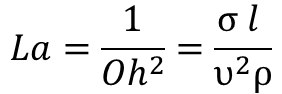

Где $\sigma$ - поверхностное натяжение,
$l$ - размер капли = $1*10^-5$,
$\nu$ - кинематическая вязкость,
$\rho$ - плотность при 20 С 

## Нигматуллин

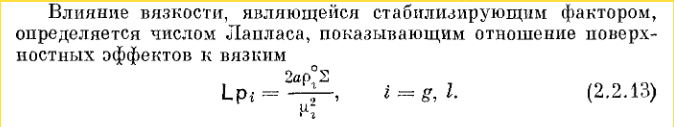

a - размер капли, $\rho$ - плотность

In [29]:
def get_laplas_numbers(fuel_combination: FuelCombination) -> float:
    surface_tension = get_surface_tension(fuel_combination)
    droplet_size = 10e-5
    viscosity = get_viscosity(fuel_combination)
    density = get_density(fuel_combination)
    
    laplas_number = (2*droplet_size*density*surface_tension) / (viscosity**2)
        
    return laplas_number

In [30]:
fuel_combinations = get_fuels_combinations()
print('Число Лапласа Нигматуллин:')
for fuel_combination in fuel_combinations:
    print(f'{fuel_combination}: {np.round(get_laplas_numbers(fuel_combination), 3)}')

Число Лапласа Нигматуллин:
diesel_steam_CO: 0.437
crude_oil_steam_CO: 0.173
heavy_oil_steam_CO: 0.001
kerosene_steam_CO: 1.89
waste_oil_steam_CO: 0.0
waste_oil_40_2024_steam_CO: 0.002
waste_oil_60_2024_steam_CO: 0.008


# Корреляционный анализ числа Лапласа и угловым коэффициентои

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


1.303764358789707
1.99636878344839
2.168189181104343
3.2388836641051446
1.2931158765725992
1.5618212827604265
1.437654140476376


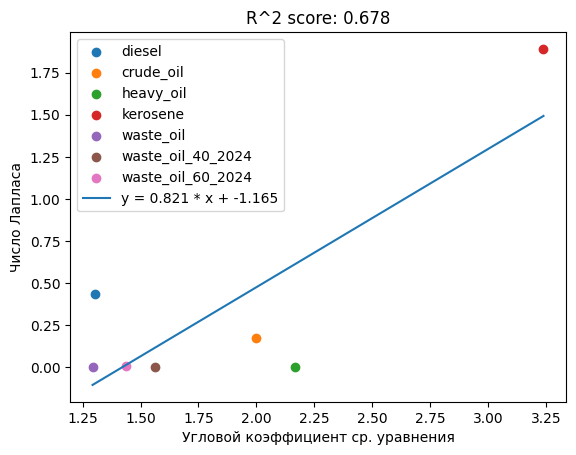

In [31]:
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, 3)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

fig, ax = plt.subplots()
laplas_numbers = dict()
angle_coeffs = dict()

for fuel_combination in diff_data:
    laplas_number = get_laplas_numbers(fuel_combination)
    laplas_numbers[fuel_combination] = laplas_number
    
    a, _ = mean_coeffs[fuel_combination]
    angle_coeffs[fuel_combination] = a
    print(a)
    plt.scatter(a, laplas_number, label=fuel_combination[:-9])

x = np.linspace(min(angle_coeffs.values()), max(angle_coeffs.values()), 100)
params, _ = curve_fit(_linear, list(angle_coeffs.values()), list(laplas_numbers.values()))
a_lap, b_lap = params
y = _linear(x, a_lap, b_lap)
plt.plot(x, y, label=f'y = {np.round(a_lap, 3)} * x + {np.round(b_lap, 3)}')

y_true = np.array(list(laplas_numbers.values()))
y_pred = _linear(np.array(list(angle_coeffs.values())), a_lap, b_lap)
r2 = r2_score(y_true, y_pred)

ax.set_ylabel('Число Лапласа')
ax.set_xlabel('Угловой коэффициент ср. уравнения')
plt.title(f'R^2 score: {np.round(r2, 3)}')

plt.legend()
plt.show()    

# Расчет доверительного интервала

$$\Delta L_p= d(L_p) = 
d(\frac{2*a*\rho *\Sigma}{\mu^2}) = 
\left(\frac{\partial L_p}{\partial \rho} + \frac{\partial L_p}{\partial \Sigma} + \frac{\partial L_p}{\partial \mu} \right) = 
\left(\frac{2a \Sigma}{\mu^2} d\rho + \frac{2a \rho}{\mu^2} d\Sigma + \frac{4a \rho \Sigma}{\mu^3} d\mu \right)
$$

$d\rho = 0.3$ кг/м^3  - погрешность при измерении плотности;
$d\Sigma = 0.01 $ mN/m - погрешность при измерении поверхностного натяжения;
$d\mu = 1$% - погрешность при измерении динамической вязкости.

## Расчет погрешности с помощью коэффициента Стьюдента

In [32]:
def get_student_surface_tension_error() -> float:
    alpha = 0.05  # уровень значимости
    n = 9
    mean = 26.4389
    std_dev = 0.55  # стандартное отклонение с коррекцией на n-1
    t_critical = stats.t.ppf(1 - alpha / 2, n - 1)  # коэффициент Стьюдента

    error = t_critical * (std_dev / np.sqrt(n))
    return error

def get_student_viscosity_error() -> float:
    alpha = 0.05  # уровень значимости
    n = 40
    mean = 47.549
    std_dev = 0.47  # стандартное отклонение с коррекцией на n-1
    t_critical = stats.t.ppf(1 - alpha / 2, n - 1)  # коэффициент Стьюдента

    error = t_critical * (std_dev / np.sqrt(n))
    return error

def get_student_density_error() -> float:
    alpha = 0.05  # уровень значимости
    n = 3
    mean = 920
    std_dev = 5  # стандартное отклонение с коррекцией на n-1
    t_critical = stats.t.ppf(1 - alpha / 2, n - 1)  # коэффициент Стьюдента

    error = t_critical * (std_dev / np.sqrt(n))
    
    return error


get_student_density_error()

12.420688559218764

In [33]:
def get_confidence_interval_for_laplas_number(fuel_combination: str, student: bool=False) -> float:
    surface_tension = get_surface_tension(fuel_combination)
    droplet_size = 10e-5
    viscosity = get_viscosity(fuel_combination)
    density = get_density(fuel_combination)

    laplas_number = get_laplas_numbers(fuel_combination)

    if student:
        student_density_error = get_student_density_error()
        student_surface_tension_error =get_student_surface_tension_error()
        student_viscosity_error = get_student_viscosity_error()
        
        density_term = (2 * droplet_size * surface_tension * student_density_error) / (viscosity**2)
        surface_tension_term = (2 * droplet_size * density * student_surface_tension_error) / (viscosity**2)
        viscosity_term = (4 * droplet_size * density * surface_tension * student_viscosity_error) / (viscosity**3)
    else:
        density_error = 0.05
        surface_tension_error = 0.05
        viscosity_error = 0.05
        
    if student:
        confidence_interval = density_term + surface_tension_term + viscosity_term
    else:
        confidence_interval = laplas_number * (density_error +  surface_tension_error + 2*viscosity_error)
    
    return confidence_interval


In [34]:
def get_confidence_interval_for_laplas_number_instrumental_error(fuel_combination: str) -> float:
    surface_tension = get_surface_tension(fuel_combination)
    droplet_size = 10e-5
    viscosity = get_viscosity(fuel_combination)
    density = get_density(fuel_combination)

    laplas_number = get_laplas_numbers(fuel_combination)

    density_error = 0.05
    surface_tension_error = 0.05
    viscosity_error = 0.05

    confidence_interval = laplas_number * (density_error +  surface_tension_error + 2*viscosity_error)
    return confidence_interval

def get_confidence_interval_for_laplas_number_instrumental_error_real(fuel_combination: str) -> float:
    """Действительная инструментальная погрешность приборов"""
    surface_tension = get_surface_tension(fuel_combination)
    droplet_size = 10e-5
    viscosity = get_viscosity(fuel_combination)
    density = get_density(fuel_combination)
    
    laplas_number = get_laplas_numbers(fuel_combination)

    density_error = 0.3
    surface_tension_error = 0.01
    viscosity_error = viscosity * 0.01

    term1 = (2*droplet_size*surface_tension/viscosity**2) * density_error
    term2 = (2*droplet_size*density/viscosity**2) * surface_tension_error
    term3 = (4*droplet_size*density*surface_tension/viscosity**3) * viscosity_error
    confidence_interval =  term1 + term2 + term3
    return confidence_interval


def get_confidence_interval_for_laplas_number_statistical_error(fuel_combination: str) -> float:
    surface_tension = get_surface_tension(fuel_combination)
    droplet_size = 10e-5
    viscosity = get_viscosity(fuel_combination)
    density = get_density(fuel_combination)

    laplas_number = get_laplas_numbers(fuel_combination)

    student_density_error = get_student_density_error()
    student_surface_tension_error =get_student_surface_tension_error()
    student_viscosity_error = get_student_viscosity_error()
    
    density_term = (2 * droplet_size * surface_tension * student_density_error) / (viscosity**2)
    surface_tension_term = (2 * droplet_size * density * student_surface_tension_error) / (viscosity**2)
    viscosity_term = (4 * droplet_size * density * surface_tension * student_viscosity_error) / (viscosity**3)

    confidence_interval = density_term + surface_tension_term + viscosity_term
    return confidence_interval

def get_confidence_interval_for_laplas_number(fuel_combination: str) -> float:
    """Инструментальная + статистическая погрешность"""
    real_instrumental_error = get_confidence_interval_for_laplas_number_instrumental_error_real(fuel_combination)
    statistical_error = get_confidence_interval_for_laplas_number_statistical_error(fuel_combination)
    

    confidence_interval = real_instrumental_error + statistical_error
    return confidence_interval
    

# Графики

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


УК: diesel_steam_CO - 1.28
УК: crude_oil_steam_CO - 1.95
УК: heavy_oil_steam_CO - 2.09
УК: kerosene_steam_CO - 3.23
УК: waste_oil_steam_CO - 1.26
УК: waste_oil_40_2024_steam_CO - 1.58
УК: waste_oil_60_2024_steam_CO - 1.25


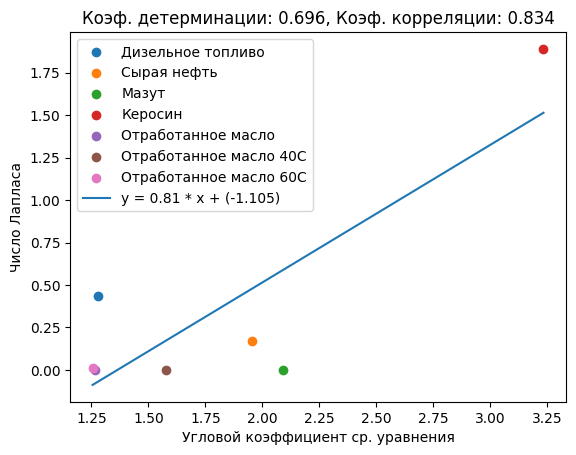

In [35]:
def title_on_russian(title: str) -> str:
    translate = {
        'diesel': 'Дизельное топливо',
        'diesel, CO': 'Дизельное топливо, CO',
        'diesel_steam': 'Дизельное топливо, пар',
        'diesel_steam_CO': 'Дизельное топливо, CO',
        'crude_oil_steam_CO': 'Сырая нефть, CO',
        'crude_oil_steam': 'Сырая нефть, пар',
        'crude_oil': 'Сырая нефть',
        'heavy_oil_steam_CO': 'Мазут, CO',
        'heavy_oil_steam': 'Мазут, пар',
        'heavy_oil': 'Мазут',
        'kerosene_steam_CO': 'Керосин, CO',
        'kerosene_steam': 'Керосин, пар',
        'kerosene': 'Керосин',
        'waste_oil_steam_CO': 'Отработанное масло, CO',
        'waste_oil_steam': 'Отработанное масло, пар',
        'waste_oil': 'Отработанное масло',
        'waste_oil_40_2024': 'Отработанное масло 40C',
        'waste_oil_60_2024': 'Отработанное масло 60C',
    }
    return translate.get(title, title)

min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, contour_level=2)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

fig, ax = plt.subplots()
laplas_numbers = dict()
angle_coeffs = dict()

# Преобразуем ключи словаря в список
keys = list(diff_data.keys())

# Исключаем последние два элемента
selected_keys = keys

for fuel_combination in selected_keys:
    laplas_number = get_laplas_numbers(fuel_combination)
    laplas_numbers[fuel_combination] = laplas_number
    error = get_confidence_interval_for_laplas_number_instrumental_error(fuel_combination)
    error = 0
    
    a, _ = mean_coeffs[fuel_combination]
    angle_coeffs[fuel_combination] = a
    print(f'УК: {fuel_combination} - {np.round(a, 2)}')
    plt.scatter(
        a,
        laplas_number,
        label=title_on_russian(fuel_combination[:-9]),
    )

x = np.linspace(min(angle_coeffs.values()), max(angle_coeffs.values()), 100)
params, _ = curve_fit(_linear, list(angle_coeffs.values()), list(laplas_numbers.values()))
a_lap, b_lap = params
y = _linear(x, a_lap, b_lap)
plt.plot(x, y, label=f'y = {np.round(a_lap, 3)} * x + ({np.round(b_lap, 3)})')

y_true = np.array(list(laplas_numbers.values()))
y_pred = _linear(np.array(list(angle_coeffs.values())), a_lap, b_lap)
r2 = r2_score(y_true, y_pred)

ax.set_ylabel('Число Лапласа')
ax.set_xlabel('Угловой коэффициент ср. уравнения')
# Вычисление коэффициента корреляции
correlation_matrix = np.corrcoef(list(angle_coeffs.values()), list(laplas_numbers.values()))
correlation_coefficient = correlation_matrix[0, 1]

# Модифицированный заголовок
plt.title(
    f'Коэф. детерминации: {np.round(r2, 3)}, '
    f'Коэф. корреляции: {np.round(correlation_coefficient, 3)}'
)

plt.legend()
plt.show()


C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


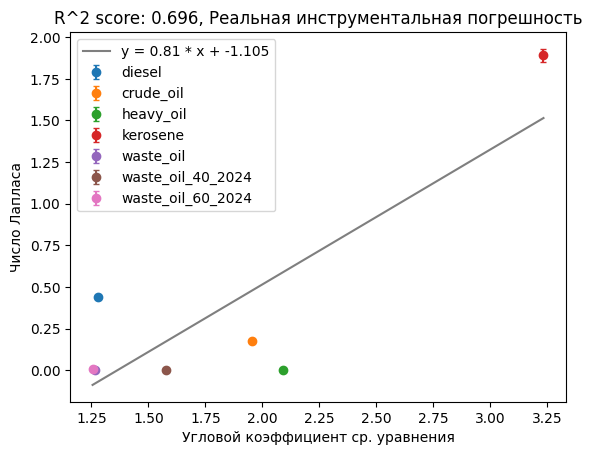

In [36]:
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, contour_level=2)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

fig, ax = plt.subplots()
laplas_numbers = dict()
angle_coeffs = dict()

for fuel_combination in diff_data:
    laplas_number = get_laplas_numbers(fuel_combination)
    laplas_numbers[fuel_combination] = laplas_number
    error = get_confidence_interval_for_laplas_number_instrumental_error_real(fuel_combination)
    
    a, _ = mean_coeffs[fuel_combination]
    angle_coeffs[fuel_combination] = a
    
    plt.errorbar(
        a,
        laplas_number,
        yerr=error,
        fmt='o',
        capsize=2,
        label=fuel_combination[:-9],
    )

x = np.linspace(min(angle_coeffs.values()), max(angle_coeffs.values()), 100)
params, _ = curve_fit(_linear, list(angle_coeffs.values()), list(laplas_numbers.values()))
a_lap, b_lap = params
y = _linear(x, a_lap, b_lap)
plt.plot(x, y, label=f'y = {np.round(a_lap, 3)} * x + {np.round(b_lap, 3)}')

y_true = np.array(list(laplas_numbers.values()))
y_pred = _linear(np.array(list(angle_coeffs.values())), a_lap, b_lap)
r2 = r2_score(y_true, y_pred)

ax.set_ylabel('Число Лапласа')
ax.set_xlabel('Угловой коэффициент ср. уравнения')
plt.title(f'R^2 score: {np.round(r2, 3)}, Реальная инструментальная погрешность')

plt.legend()
plt.show()

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


diesel_steam_CO - 1.2797515347258315
crude_oil_steam_CO - 1.9524286296772309
heavy_oil_steam_CO - 2.090314961752629
kerosene_steam_CO - 3.233682400052805
waste_oil_steam_CO - 1.2633412147971441
waste_oil_40_2024_steam_CO - 1.5761696290628504
waste_oil_60_2024_steam_CO - 1.254824690952249


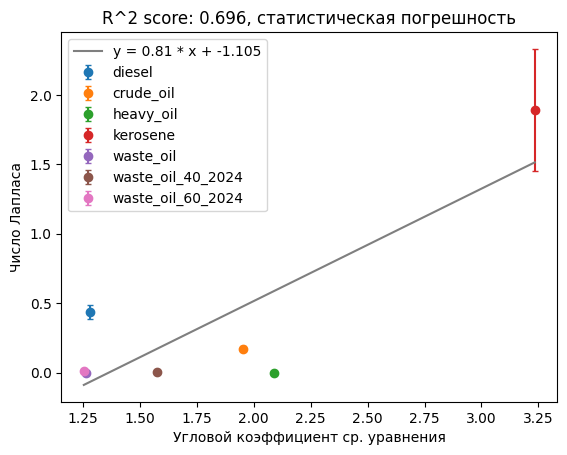

In [37]:
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, contour_level=2)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

fig, ax = plt.subplots()
laplas_numbers = dict()
angle_coeffs = dict()

for fuel_combination in diff_data:
    laplas_number = get_laplas_numbers(fuel_combination)
    laplas_numbers[fuel_combination] = laplas_number
    error = get_confidence_interval_for_laplas_number_statistical_error(fuel_combination)
    
    a, _ = mean_coeffs[fuel_combination]
    angle_coeffs[fuel_combination] = a
    print(f'{fuel_combination} - {a}')
    
    plt.errorbar(
        a,
        laplas_number,
        yerr=error,
        fmt='o',
        capsize=2,
        label=fuel_combination[:-9],
    )

x = np.linspace(min(angle_coeffs.values()), max(angle_coeffs.values()), 100)
params, _ = curve_fit(_linear, list(angle_coeffs.values()), list(laplas_numbers.values()))
a_lap, b_lap = params
y = _linear(x, a_lap, b_lap)
plt.plot(x, y, label=f'y = {np.round(a_lap, 3)} * x + {np.round(b_lap, 3)}')

y_true = np.array(list(laplas_numbers.values()))
y_pred = _linear(np.array(list(angle_coeffs.values())), a_lap, b_lap)
r2 = r2_score(y_true, y_pred)

ax.set_ylabel('Число Лапласа')
ax.set_xlabel('Угловой коэффициент ср. уравнения')
plt.title(f'R^2 score: {np.round(r2, 3)}, статистическая погрешность')

plt.legend()
plt.show()

# 

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


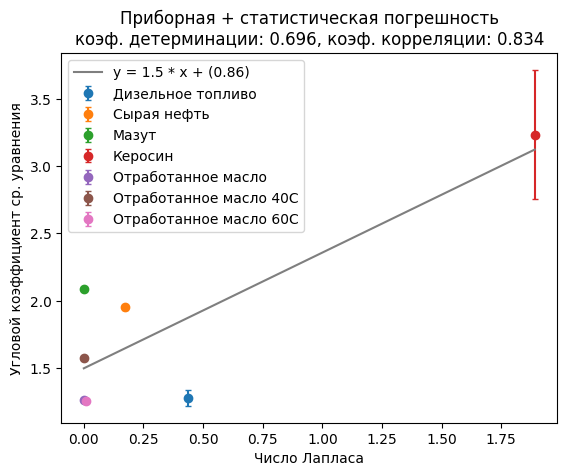

In [69]:
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, contour_level=2)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

fig, ax = plt.subplots()
laplas_numbers = dict()
angle_coeffs = dict()

for fuel_combination in diff_data:
    laplas_number = get_laplas_numbers(fuel_combination)
    laplas_numbers[fuel_combination] = laplas_number
    error = get_confidence_interval_for_laplas_number(fuel_combination)
    
    a, _ = mean_coeffs[fuel_combination]
    angle_coeffs[fuel_combination] = a
    
    plt.errorbar(
        laplas_number,
        a,
        yerr=error,
        fmt='o',
        capsize=2,
        label=title_on_russian(fuel_combination[:-9]),
    )

x = np.linspace(min(laplas_numbers.values()), max(laplas_numbers.values()), 100)
params, _ = curve_fit(_linear, list(laplas_numbers.values()), list(angle_coeffs.values()))
a_ang, b_ang = params
y = _linear(x, a_ang, b_ang)
plt.plot(x, y, label=f'y = {np.round(a_lap, 2)} * x + ({np.round(b_lap, 2)})')

y_true = np.array(list(angle_coeffs.values()))
y_pred = _linear(np.array(list(laplas_numbers.values())), a_ang, b_ang)
r2 = r2_score(y_true, y_pred)

ax.set_xlabel('Число Лапласа')
ax.set_ylabel('Угловой коэффициент ср. уравнения')
# Вычисление коэффициента корреляции
correlation_matrix = np.corrcoef(list(laplas_numbers.values()), list(angle_coeffs.values()))
correlation_coefficient = correlation_matrix[0, 1]

# Модифицированный заголовок
plt.title(
    f'Приборная + статистическая погрешность\n'
    f'коэф. детерминации: {np.round(r2, 3)}, '
    f'коэф. корреляции: {np.round(correlation_coefficient, 3)}'
)

plt.legend()
plt.show()

In [39]:
def get_ohnezorge_numbers(fuel_combination: FuelCombination) -> float:
    laplas_number = get_laplas_numbers(fuel_combination)
    
    return 1/np.sqrt(laplas_number)

C:\Users\evils\AppData\Local\Temp\ipykernel_8496\4020167938.py:194: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[contour_level]


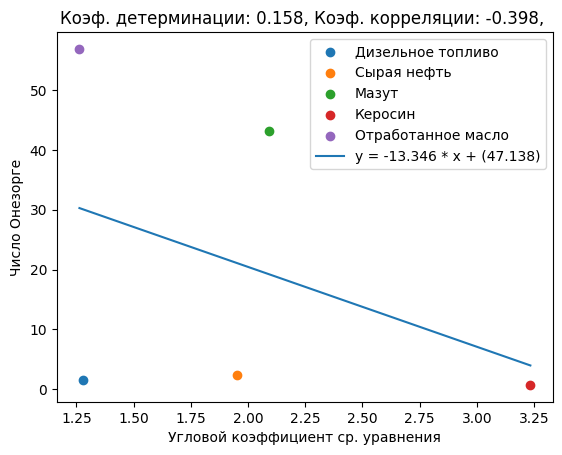

In [40]:
min_CO_coeffs = get_linear_coeffs_min_CO()
diff_data = get_diff_data()
div_line_coeffs_high_line = get_linear_coeffs_div_line(diff_data, contour_level=2)
mean_coeffs = get_mean_coeffs(div_line_coeffs_high_line, min_CO_coeffs)

fig, ax = plt.subplots()
ohnezorge_numbers = dict()
angle_coeffs = dict()

# Преобразуем ключи словаря в список
keys = list(diff_data.keys())

# Исключаем последние два элемента
selected_keys = keys[:-2]

for fuel_combination in selected_keys:
    ohnezorge_number = get_ohnezorge_numbers(fuel_combination)
    ohnezorge_numbers[fuel_combination] = ohnezorge_number
    error = get_confidence_interval_for_laplas_number(fuel_combination)
    
    a, _ = mean_coeffs[fuel_combination]
    angle_coeffs[fuel_combination] = a
    
    plt.scatter(
        a,
        ohnezorge_number,
        label=title_on_russian(fuel_combination[:-9]),
    )

x = np.linspace(min(angle_coeffs.values()), max(angle_coeffs.values()), 100)
params, _ = curve_fit(_linear, list(angle_coeffs.values()), list(ohnezorge_numbers.values()))
a_lap, b_lap = params
y = _linear(x, a_lap, b_lap)
plt.plot(x, y, label=f'y = {np.round(a_lap, 3)} * x + ({np.round(b_lap, 3)})')

y_true = np.array(list(ohnezorge_numbers.values()))
y_pred = _linear(np.array(list(angle_coeffs.values())), a_lap, b_lap)
r2 = r2_score(y_true, y_pred)

ax.set_ylabel('Число Онезорге')
ax.set_xlabel('Угловой коэффициент ср. уравнения')
# Вычисление коэффициента корреляции
correlation_matrix = np.corrcoef(list(angle_coeffs.values()), list(ohnezorge_numbers.values()))
correlation_coefficient = correlation_matrix[0, 1]

# Модифицированный заголовок
plt.title(
    f'Коэф. детерминации: {np.round(r2, 3)}, '
    f'Коэф. корреляции: {np.round(correlation_coefficient, 3)}, '
)

plt.legend()
plt.show()